# Image Pyramids: Gaussian & Laplacian

Notebook dimostrativo per capire:
- Come si costruisce una **Gaussian pyramid**
- Come si costruisce una **Laplacian pyramid**
- Perché la Laplacian è **lossless** e la Gaussian no
- Come funziona la **ricostruzione perfetta**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ── helpers ──────────────────────────────────────────────────────────────────

def reduce(img):
    """REDUCE: blur then downsample by 2."""
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    return blurred[::2, ::2]          # subsample every other pixel

def expand(img, target_shape=None):
    """EXPAND: upsample then blur. Optionally crop/pad to target_shape."""
    h, w = img.shape[:2]
    up = np.zeros((h * 2, w * 2) + img.shape[2:], dtype=np.float64)
    up[::2, ::2] = img               # insert pixels at even positions
    up = cv2.GaussianBlur(up, (5, 5), 0) * 4  # ×4 to compensate zeros
    if target_shape is not None:
        th, tw = target_shape[:2]
        up = up[:th, :tw]            # crop to match original size
    return up

def build_gaussian_pyramid(img, levels):
    pyr = [img.astype(np.float64)]
    for _ in range(levels - 1):
        pyr.append(reduce(pyr[-1]))
    return pyr

def build_laplacian_pyramid(gaussian_pyr):
    pyr = []
    for i in range(len(gaussian_pyr) - 1):
        G_i      = gaussian_pyr[i]
        G_i1_exp = expand(gaussian_pyr[i + 1], target_shape=G_i.shape)
        pyr.append(G_i - G_i1_exp)  # residual: what EXPAND loses
    pyr.append(gaussian_pyr[-1])    # coarsest level stored as-is
    return pyr

def reconstruct_from_laplacian(lap_pyr):
    G = lap_pyr[-1].copy()
    for L in reversed(lap_pyr[:-1]):
        G = expand(G, target_shape=L.shape) + L
    return G

def clip_show(img):
    """Normalize float image to [0,255] uint8 for display."""
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

def show_residual(ax, residual, title):
    """Display a residual (signed) with diverging colormap centered at 0."""
    if residual.ndim == 3:
        r = residual[:, :, 0]   # show just red channel for clarity
    else:
        r = residual
    vmax = max(abs(r.min()), abs(r.max()), 1e-6)
    ax.imshow(r, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

print('Helper functions ready.')

Helper functions ready.


Immagine originale: 1200×1107


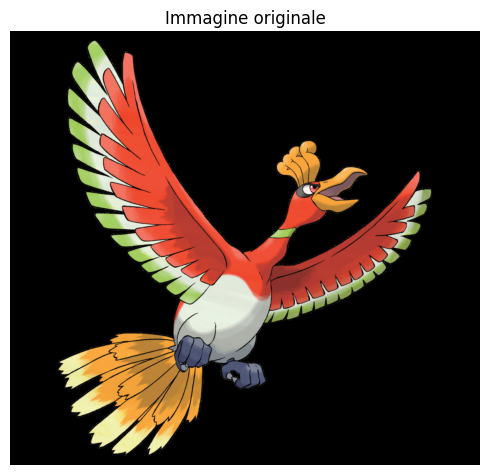

In [2]:
# ── load image ───────────────────────────────────────────────────────────────
img_bgr = cv2.imread('images/Ho-oh.png')
if img_bgr is None:
    raise FileNotFoundError('Immagine non trovata in images/Ho-oh.png')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# resize to power-of-2 friendly size for clean pyramid
H, W = img_rgb.shape[:2]
print(f'Immagine originale: {W}×{H}')

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title('Immagine originale')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 1 · Gaussian Pyramid

Ogni livello = `REDUCE(livello precedente)` = blur + subsample.

Perdo dettagli ad alta frequenza → **lossy**.

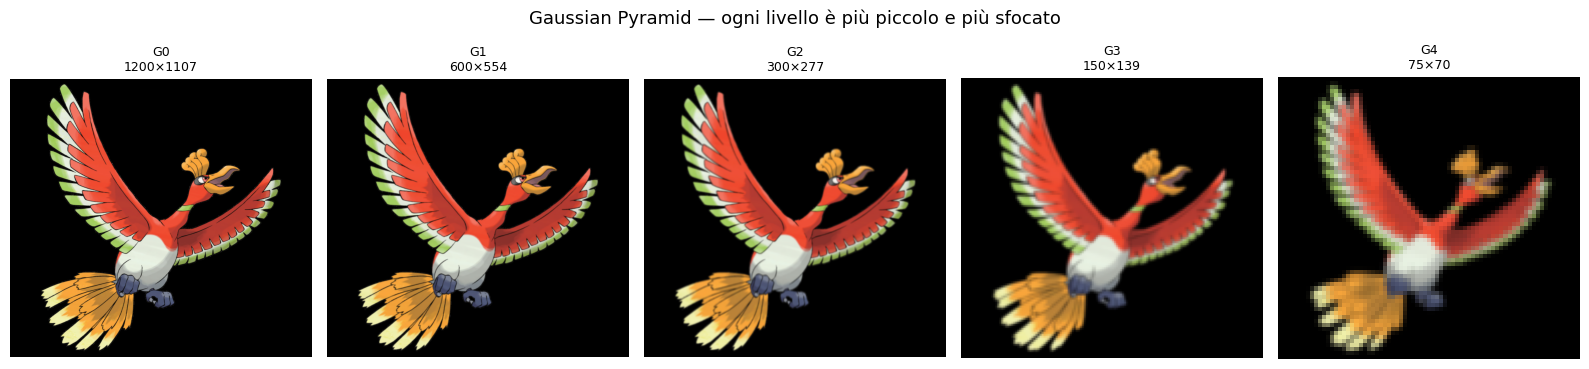

Pixel per livello: [3985200, 997200, 249300, 62550, 15750]
Totale piramide: 5,310,000  vs originale 3,985,200
Overhead: 1.332× ≈ 4/3 = 1.333×


In [3]:
LEVELS = 5
gauss_pyr = build_gaussian_pyramid(img_rgb, LEVELS)

fig, axes = plt.subplots(1, LEVELS, figsize=(16, 4))
fig.suptitle('Gaussian Pyramid — ogni livello è più piccolo e più sfocato', fontsize=13)

for i, (ax, G) in enumerate(zip(axes, gauss_pyr)):
    h, w = G.shape[:2]
    ax.imshow(clip_show(G))
    ax.set_title(f'G{i}\n{w}×{h}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# storage comparison
sizes = [G.size for G in gauss_pyr]
print('Pixel per livello:', sizes)
print(f'Totale piramide: {sum(sizes):,}  vs originale {sizes[0]:,}')
print(f'Overhead: {sum(sizes)/sizes[0]:.3f}× ≈ 4/3 = 1.333×')

### Perché lossy? Dimostrazione

Proviamo a ricostruire G0 (originale) da G1 con un semplice `EXPAND`. Vediamo cosa si perde.

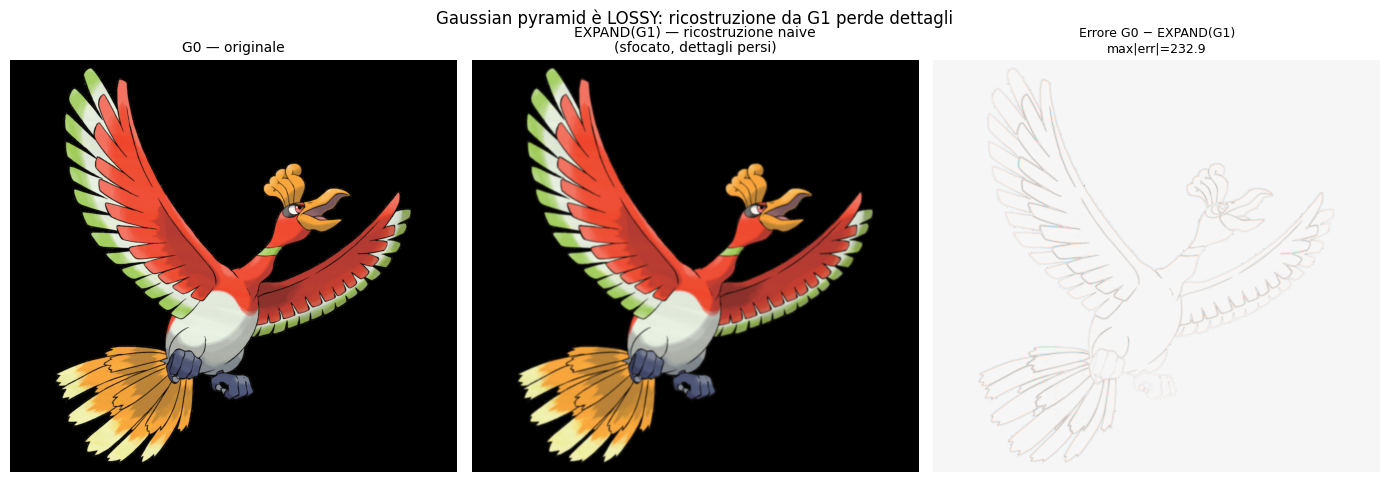

In [4]:
G0 = gauss_pyr[0]
G1 = gauss_pyr[1]

G0_reconstructed_naive = expand(G1, target_shape=G0.shape)
diff_naive = G0.astype(np.float64) - G0_reconstructed_naive

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Gaussian pyramid è LOSSY: ricostruzione da G1 perde dettagli', fontsize=12)

axes[0].imshow(clip_show(G0))
axes[0].set_title('G0 — originale', fontsize=10)
axes[0].axis('off')

axes[1].imshow(clip_show(G0_reconstructed_naive))
axes[1].set_title('EXPAND(G1) — ricostruzione naive\n(sfocato, dettagli persi)', fontsize=10)
axes[1].axis('off')

show_residual(axes[2], diff_naive[:, :, 0],
              f'Errore G0 − EXPAND(G1)\nmax|err|={np.abs(diff_naive).max():.1f}')

plt.tight_layout()
plt.show()

---
## 2 · Laplacian Pyramid

Salva ciò che `EXPAND` perde → residui = **alte frequenze**.  

$$L_i = G_i - \text{EXPAND}(G_{i+1})$$

Rappresentazione **lossless**: posso ricostruire G0 esattamente.

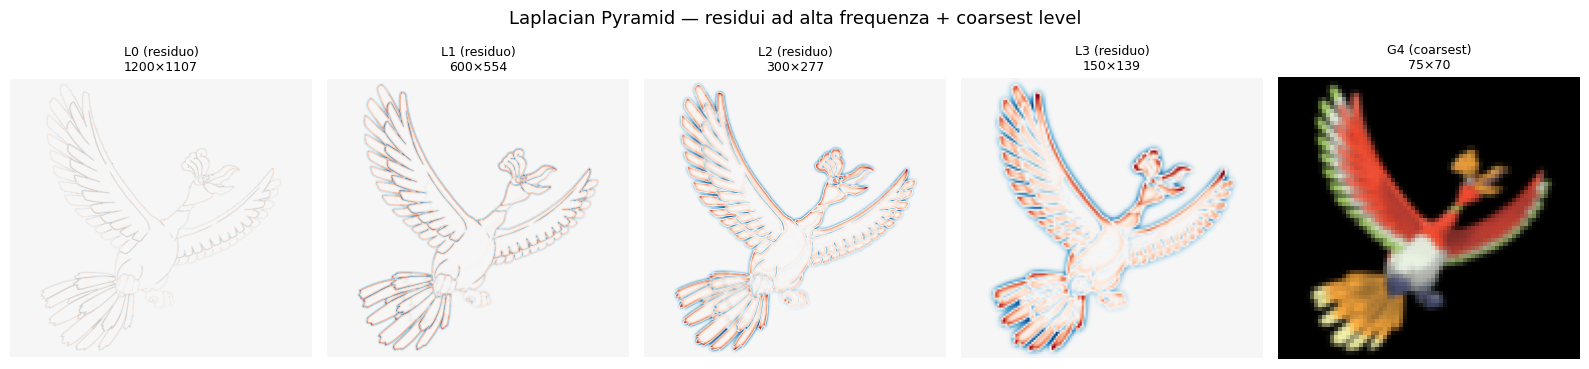

Nota: i residui sembrano quasi neri → valori vicini a zero
Ma contengono le alte frequenze necessarie per ricostruzione perfetta.
  L0: min=-131.2, max=232.9, std=9.73
  L1: min=-114.6, max=113.8, std=9.95
  L2: min=-108.9, max=100.7, std=11.15
  L3: min=-102.6, max=102.2, std=13.60


In [5]:
lap_pyr = build_laplacian_pyramid(gauss_pyr)

fig, axes = plt.subplots(1, LEVELS, figsize=(16, 4))
fig.suptitle('Laplacian Pyramid — residui ad alta frequenza + coarsest level', fontsize=13)

for i, ax in enumerate(axes):
    L = lap_pyr[i]
    h, w = L.shape[:2]
    if i < LEVELS - 1:
        show_residual(ax, L, f'L{i} (residuo)\n{w}×{h}')
    else:
        ax.imshow(clip_show(L))
        ax.set_title(f'G{i} (coarsest)\n{w}×{h}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

print('Nota: i residui sembrano quasi neri → valori vicini a zero')
print('Ma contengono le alte frequenze necessarie per ricostruzione perfetta.')
for i, L in enumerate(lap_pyr[:-1]):
    print(f'  L{i}: min={L.min():.1f}, max={L.max():.1f}, std={L.std():.2f}')

### Zoom sui residui Laplaciani

Amplificando il contrasto si vedono i bordi e i dettagli salvati.

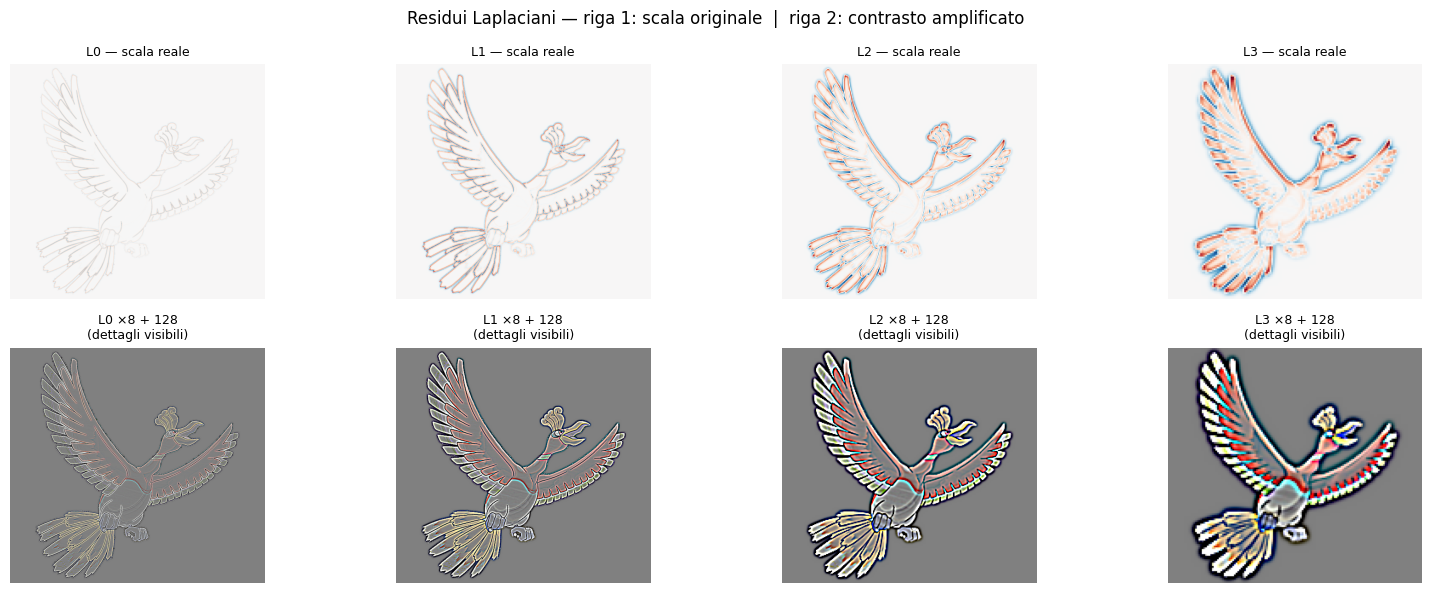

In [6]:
fig, axes = plt.subplots(2, LEVELS - 1, figsize=(16, 6))
fig.suptitle('Residui Laplaciani — riga 1: scala originale  |  riga 2: contrasto amplificato', fontsize=12)

for i in range(LEVELS - 1):
    L = lap_pyr[i]
    # riga 1: colormap divergente
    show_residual(axes[0, i], L, f'L{i} — scala reale')
    # riga 2: amplificato ×8
    amplified = np.clip(L * 8 + 128, 0, 255).astype(np.uint8)
    axes[1, i].imshow(amplified)
    axes[1, i].set_title(f'L{i} ×8 + 128\n(dettagli visibili)', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 3 · Ricostruzione perfetta dalla Laplacian

$$G_i = L_i + \text{EXPAND}(G_{i+1})$$

Partiamo da `G_n` (coarsest) e risaliamo sommando i residui.

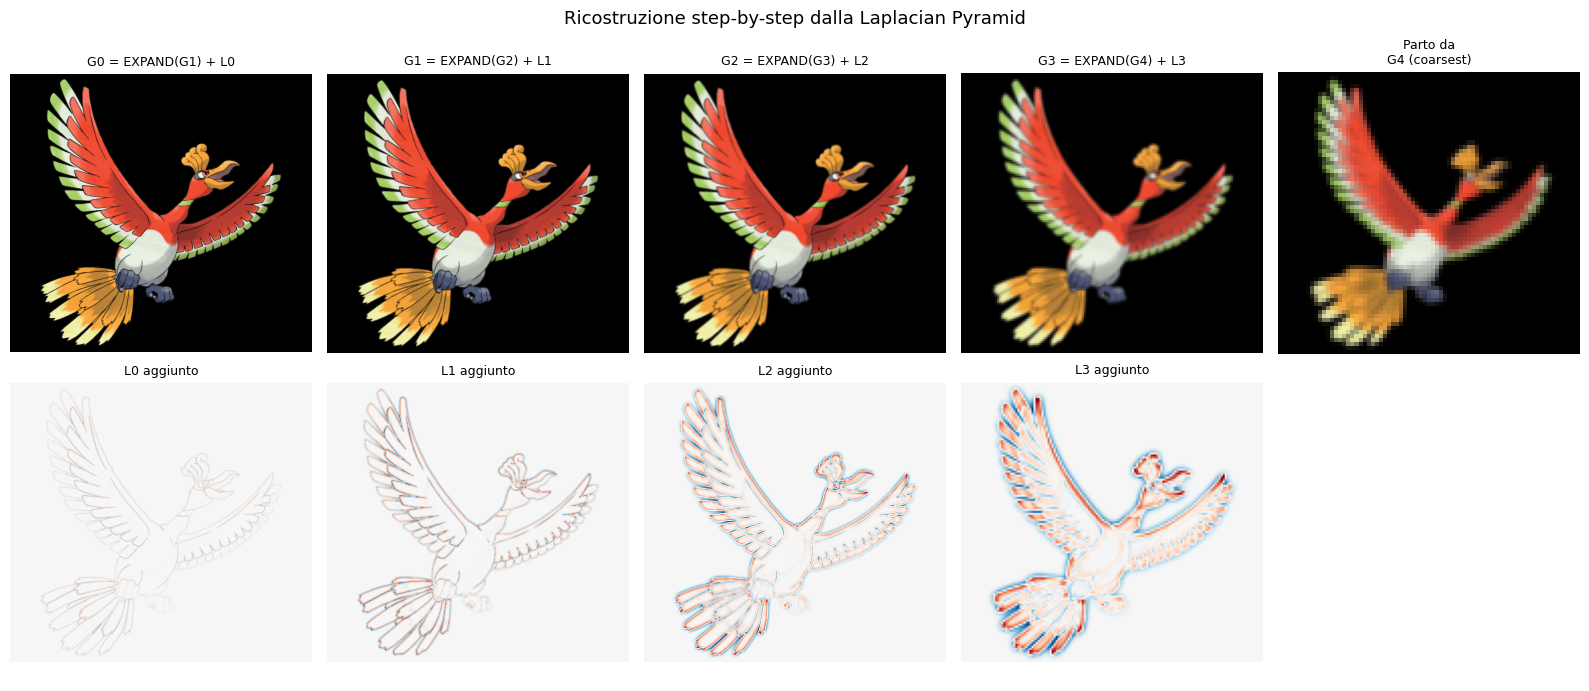

Errore ricostruzione: max=0.000000, mean=0.000000
→ Errore quasi zero = ricostruzione perfetta (solo floating point noise)


In [7]:
# step-by-step reconstruction visualization
fig, axes = plt.subplots(2, LEVELS, figsize=(16, 7))
fig.suptitle('Ricostruzione step-by-step dalla Laplacian Pyramid', fontsize=13)

G_current = lap_pyr[-1].copy()

# show coarsest
axes[0, LEVELS - 1].imshow(clip_show(G_current))
axes[0, LEVELS - 1].set_title(f'Parto da\nG{LEVELS-1} (coarsest)', fontsize=9)
axes[0, LEVELS - 1].axis('off')
axes[1, LEVELS - 1].axis('off')

for idx, i in enumerate(range(LEVELS - 2, -1, -1)):
    col = i  # column in subplot grid
    L = lap_pyr[i]
    expanded = expand(G_current, target_shape=L.shape)
    G_current = expanded + L

    axes[0, col].imshow(clip_show(G_current))
    axes[0, col].set_title(f'G{i} = EXPAND(G{i+1}) + L{i}', fontsize=9)
    axes[0, col].axis('off')

    # show the residual L_i being added
    show_residual(axes[1, col], L, f'L{i} aggiunto')

plt.tight_layout()
plt.show()

# quantify reconstruction error
reconstructed = reconstruct_from_laplacian(lap_pyr)
error = np.abs(img_rgb.astype(np.float64) - reconstructed)
print(f'Errore ricostruzione: max={error.max():.6f}, mean={error.mean():.6f}')
print('→ Errore quasi zero = ricostruzione perfetta (solo floating point noise)')

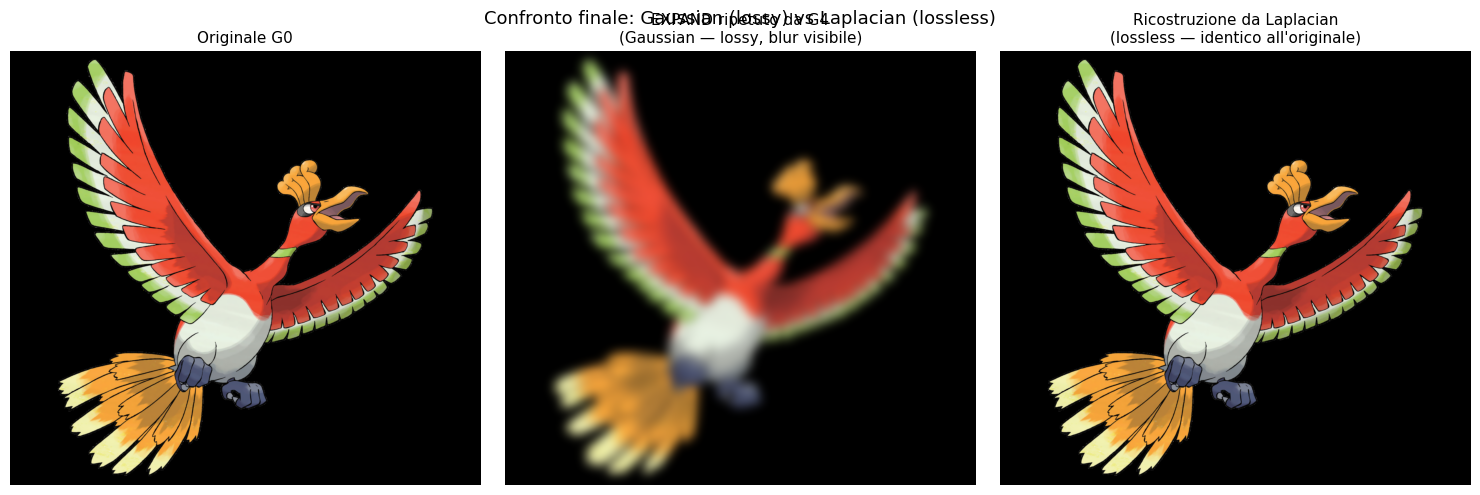

In [8]:
# confronto finale: originale vs ricostruito vs errore
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confronto finale: Gaussian (lossy) vs Laplacian (lossless)', fontsize=13)

axes[0].imshow(img_rgb)
axes[0].set_title('Originale G0', fontsize=11)
axes[0].axis('off')

# gaussian 'reconstruction' (naive EXPAND from top level)
G_naive = gauss_pyr[-1].copy()
for i in range(LEVELS - 2, -1, -1):
    G_naive = expand(G_naive, target_shape=gauss_pyr[i].shape)
axes[1].imshow(clip_show(G_naive))
axes[1].set_title(f'EXPAND ripetuto da G{LEVELS-1}\n(Gaussian — lossy, blur visibile)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(clip_show(reconstructed))
axes[2].set_title('Ricostruzione da Laplacian\n(lossless — identico all\'originale)', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## 4 · Frequenze per livello

Ogni livello Laplaciano cattura una banda di frequenze diversa.  
L0 = alta frequenza (dettagli fini), L_n-1 = bassa frequenza (struttura globale).

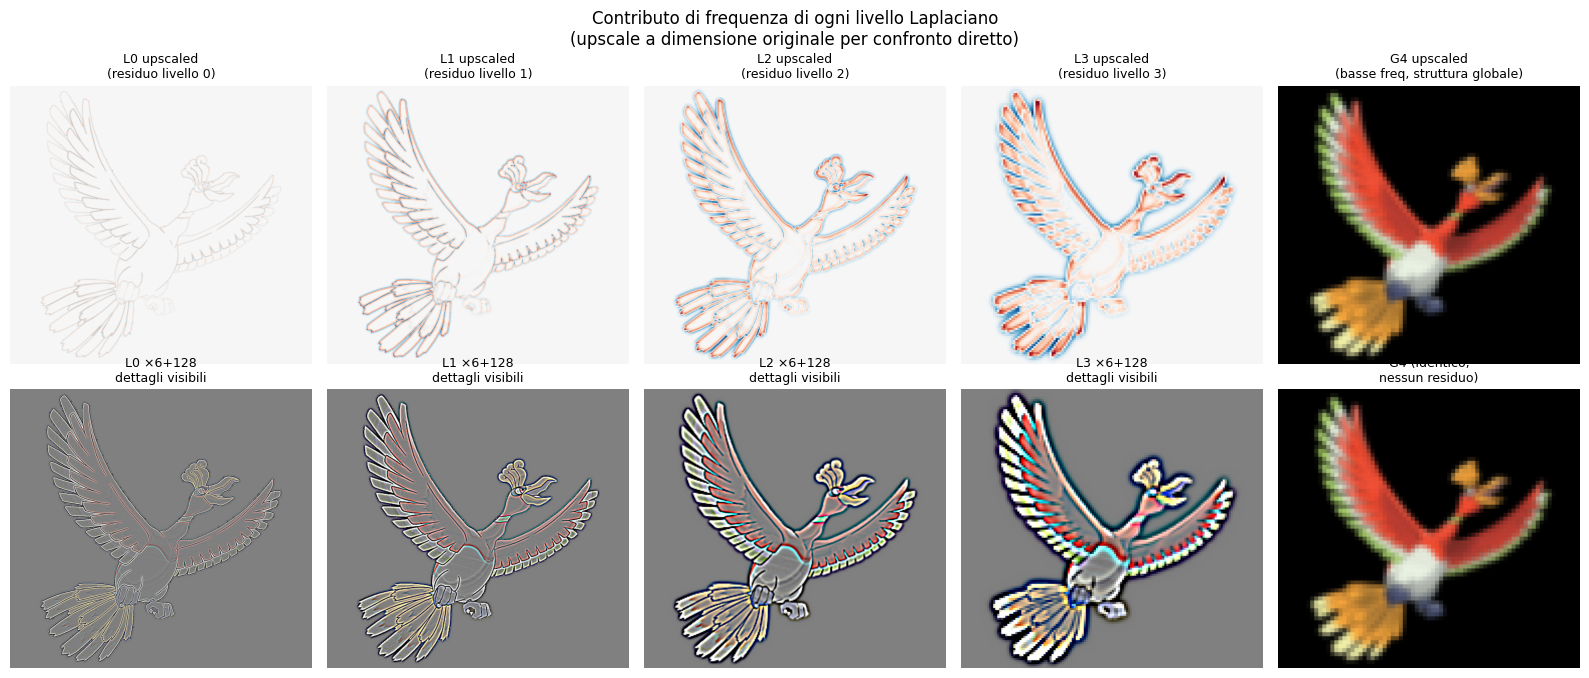

In [9]:
# upscale each Laplacian level back to original size for direct comparison
fig, axes = plt.subplots(2, LEVELS, figsize=(16, 7))
fig.suptitle('Contributo di frequenza di ogni livello Laplaciano\n(upscale a dimensione originale per confronto diretto)', fontsize=12)

orig_shape = img_rgb.shape

for i in range(LEVELS - 1):
    L = lap_pyr[i].copy()
    # upsample to original size
    L_up = cv2.resize(L, (orig_shape[1], orig_shape[0]), interpolation=cv2.INTER_NEAREST)
    show_residual(axes[0, i], L_up, f'L{i} upscaled\n(residuo livello {i})')

    # same but amplified for visibility
    L_amp = np.clip(L_up * 6 + 128, 0, 255).astype(np.uint8)
    axes[1, i].imshow(L_amp)
    axes[1, i].set_title(f'L{i} ×6+128\ndettagli visibili', fontsize=9)
    axes[1, i].axis('off')

# last level: the coarsest Gaussian
G_top = gauss_pyr[-1]
G_top_up = cv2.resize(G_top.astype(np.uint8), (orig_shape[1], orig_shape[0]), interpolation=cv2.INTER_NEAREST)
axes[0, -1].imshow(G_top_up)
axes[0, -1].set_title(f'G{LEVELS-1} upscaled\n(basse freq, struttura globale)', fontsize=9)
axes[0, -1].axis('off')
axes[1, -1].imshow(G_top_up)
axes[1, -1].set_title(f'G{LEVELS-1} (identico,\nnessun residuo)', fontsize=9)
axes[1, -1].axis('off')

plt.tight_layout()
plt.show()

---
## 5 · Curiosità: Image Blending con Laplacian pyramid

Applicazione classica: fondere due immagini senza giunture visibili.  
Si fondono le piramidi Laplaciane e poi si ricostruisce.

Esempio: metà sinistra vs metà destra dell'immagine originale (flip orizzontale).

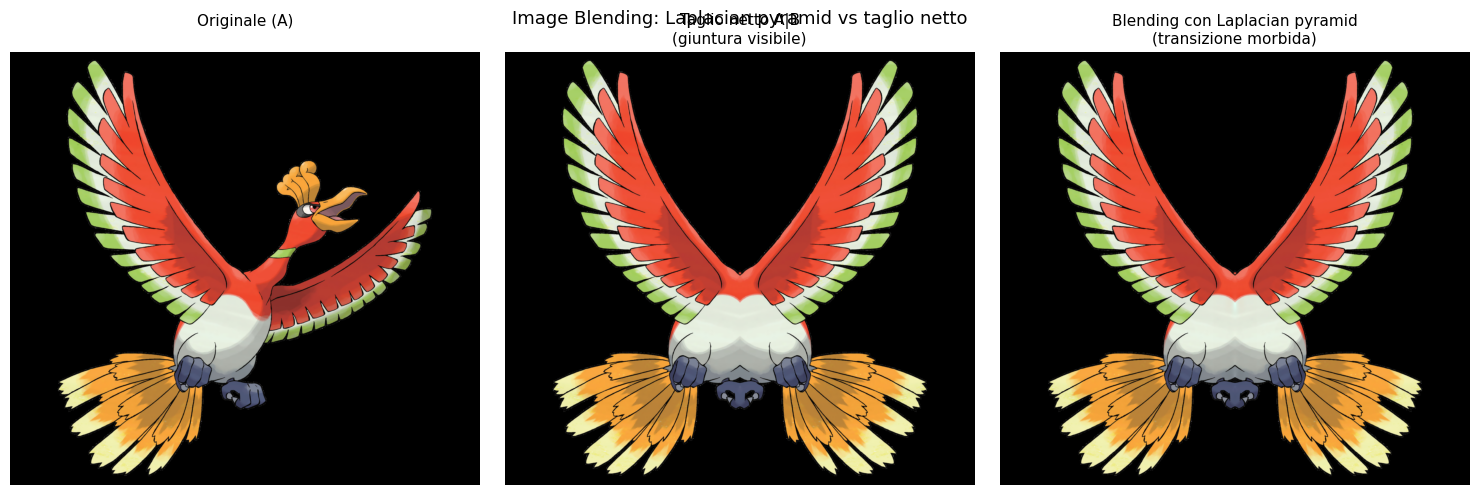

Il blending Laplaciano fonde le frequenze gradualmente per ogni scala:
→ bordi fini (L0) vengono tenuti locali
→ struttura globale (G_n) viene miscelata con transizione ampia


In [10]:
img_A = img_rgb.astype(np.float64)
img_B = np.fliplr(img_rgb).astype(np.float64)

# build pyramids for both
gA = build_gaussian_pyramid(img_A, LEVELS)
gB = build_gaussian_pyramid(img_B, LEVELS)
lA = build_laplacian_pyramid(gA)
lB = build_laplacian_pyramid(gB)

# build mask pyramid: left half=1, right half=0
mask = np.zeros_like(img_A)
mask[:, :img_A.shape[1] // 2] = 1.0
gM = build_gaussian_pyramid(mask, LEVELS)

# blend each Laplacian level
lap_blend = []
for i in range(LEVELS):
    m = gM[i]
    blended_level = lA[i] * m + lB[i] * (1 - m)
    lap_blend.append(blended_level)

# reconstruct
blended_img   = reconstruct_from_laplacian(lap_blend)
# naive blend (direct cut) for comparison
naive_blend   = img_A.copy()
naive_blend[:, img_A.shape[1] // 2:] = img_B[:, img_A.shape[1] // 2:]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Image Blending: Laplacian pyramid vs taglio netto', fontsize=13)

axes[0].imshow(img_rgb)
axes[0].set_title('Originale (A)\n', fontsize=11)
axes[0].axis('off')

axes[1].imshow(clip_show(naive_blend))
axes[1].set_title('Taglio netto A|B\n(giuntura visibile)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(clip_show(blended_img))
axes[2].set_title('Blending con Laplacian pyramid\n(transizione morbida)', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('Il blending Laplaciano fonde le frequenze gradualmente per ogni scala:')
print('→ bordi fini (L0) vengono tenuti locali')
print('→ struttura globale (G_n) viene miscelata con transizione ampia')

---
## 6 · Riepilogo visivo: cosa contiene ogni struttura

| | Gaussian pyramid | Laplacian pyramid |
|---|---|---|
| **Cosa memorizza** | Immagine smoothed ad ogni scala | Residui (alte freq) + coarsest |
| **Lossy/Lossless** | Lossy — no ricostruzione esatta | Lossless — ricostruzione esatta |
| **Uso** | Coarse-to-fine search, feature matching | Compressione, blending, tone mapping |
| **Storage** | ≈4/3 × originale | ≈4/3 × originale (uguale!) |
| **Frequenze** | Ogni livello = bande sempre più basse | Ogni livello = banda specifica |

### Relazione fondamentale

```
G_{i+1} = REDUCE(G_i)          ← costruzione Gaussian
L_i     = G_i - EXPAND(G_{i+1}) ← costruzione Laplacian (salva ciò che si perde)
G_i     = L_i + EXPAND(G_{i+1}) ← ricostruzione perfetta
```

La Laplacian pyramid = Gaussian pyramid + i "pezzi mancanti".